# Beat the Crime: Data-Driven Patrol Optimization for Chicago
**CSCI 347 — Data Mining | Final Project — Part 2**
**John Nelson, Henry Stickling, and Lucas Jones**

**Dataset:** [Chicago Crimes 2012–2017 (Kaggle)](https://www.kaggle.com/datasets/currie32/crimes-in-chicago)

**Pipeline Overview:**
1. Data Loading & EDA
2. Preprocessing
3. Dimensionality Reduction (PCA)
4. Spatial Clustering — K-Means
5. Spatial Clustering — DBSCAN
6. Outlier Detection — Isolation Forest
7. Predictive Modeling — Random Forest
8. Patrol Distance Analysis
9. Crime Trend Visualizations

---
## 0. Imports & Setup

In [1]:
import kagglehub
import pandas as pd

# Download the dataset files
path = kagglehub.dataset_download("currie32/crimes-in-chicago")

# Load directly with pandas
df = pd.read_csv(
    f"{path}/Chicago_Crimes_2012_to_2017.csv",
    encoding="latin-1",
    on_bad_lines="skip",
    engine="python"  # python engine is more tolerant than the default C engine
)

print("First 5 records:", df.head())

c:\Users\jones\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First 5 records:    Unnamed: 0        ID Case Number                    Date  \
0           3  10508693    HZ250496  05/03/2016 11:40:00 PM   
1          89  10508695    HZ250409  05/03/2016 09:40:00 PM   
2         197  10508697    HZ250503  05/03/2016 11:31:00 PM   
3         673  10508698    HZ250424  05/03/2016 10:10:00 PM   
4         911  10508699    HZ250455  05/03/2016 10:00:00 PM   

                 Block  IUCR            Primary Type              Description  \
0   013XX S SAWYER AVE  0486                 BATTERY  DOMESTIC BATTERY SIMPLE   
1   061XX S DREXEL AVE  0486                 BATTERY  DOMESTIC BATTERY SIMPLE   
2  053XX W CHICAGO AVE  0470  PUBLIC PEACE VIOLATION         RECKLESS CONDUCT   
3    049XX W FULTON ST  0460                 BATTERY                   SIMPLE   
4    003XX N LOTUS AVE  0820                   THEFT           $500 AND UNDER   

  Location Description  Arrest  ...  Ward  Community Area  FBI Code  \
0            APARTMENT    True  ...  24.0     

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif'
})

print('Setup complete.')

Setup complete.


---
## 1. Data Loading

In [5]:
print('Column names:')
print(df.columns.tolist())
print()
print('Data types:')
print(df.dtypes)

Column names:
['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']

Data types:
Unnamed: 0                int64
ID                        int64
Case Number                 str
Date                        str
Block                       str
IUCR                        str
Primary Type                str
Description                 str
Location Description        str
Arrest                     bool
Domestic                   bool
Beat                      int64
District                float64
Ward                    float64
Community Area          float64
FBI Code                    str
X Coordinate            float64
Y Coordinate            float64
Year                      int64
Updated On                  str
Latitude                float64
Longitude     

---
## 2. Exploratory Data Analysis

In [6]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
Case Number,1,0.00
Location Description,1658,0.11
District,1,0.00
Ward,14,0.00
Community Area,40,0.00
X Coordinate,37083,2.55
Y Coordinate,37083,2.55
Latitude,37083,2.55
Longitude,37083,2.55
Location,37083,2.55


In [7]:
print('Top 10 crime types:')
print(df['Primary Type'].value_counts().head(10))

Top 10 crime types:
Primary Type
THEFT                  329460
BATTERY                263700
CRIMINAL DAMAGE        155455
NARCOTICS              135240
ASSAULT                 91289
OTHER OFFENSE           87874
BURGLARY                83397
DECEPTIVE PRACTICE      75495
MOTOR VEHICLE THEFT     61138
ROBBERY                 57313
Name: count, dtype: int64


In [8]:
# Basic statistics for numerical columns
df.describe()

,Unnamed: 0,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude
count,1.456714e+06,1.456714e+06,1.456714e+06,1.456713e+06,1.456700e+06,1.456674e+06,1.419631e+06,1.419631e+06,1.456714e+06,1.419631e+06,1.419631e+06
mean,3.308606e+06,9.597550e+06,1.150644e+03,1.125920e+01,2.287027e+01,3.745632e+01,1.164398e+06,1.885523e+06,2.013897e+03,4.184147e+01,-8.767224e+01
std,1.235350e+06,8.083505e+05,6.916466e+02,6.904691e+00,1.380589e+01,2.144029e+01,1.850835e+04,3.424775e+04,1.449584e+00,9.430126e-02,6.661726e-02
min,3.000000e+00,2.022400e+04,1.110000e+02,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.012000e+03,3.661945e+01,-9.168657e+01
25%,2.698636e+06,9.002709e+06,6.130000e+02,6.000000e+00,1.000000e+01,2.300000e+01,1.152544e+06,1.858762e+06,2.013000e+03,4.176787e+01,-8.771528e+01
50%,3.063654e+06,9.605776e+06,1.024000e+03,1.000000e+01,2.300000e+01,3.200000e+01,1.166021e+06,1.891502e+06,2.014000e+03,4.185797e+01,-8.766613e+01
75%,3.428849e+06,1.022577e+07,1.711000e+03,1.700000e+01,3.400000e+01,5.600000e+01,1.176363e+06,1.908713e+06,2.015000e+03,4.190529e+01,-8.762813e+01
max,6.253474e+06,1.082788e+07,2.535000e+03,3.100000e+01,5.000000e+01,7.700000e+01,1.205119e+06,1.951573e+06,2.017000e+03,4.202271e+01,-8.752453e+01


---
## 3. Preprocessing

### 3a. Drop Rows with Missing Geographic Coordinates
Crimes without lat/lon are useless for spatial analysis and cannot be imputed meaningfully.

In [9]:
before = len(df)
df.dropna(subset=['Latitude', 'Longitude'], inplace=True)
print(f'Rows dropped (no coordinates): {before - len(df):,}')
print(f'Shape after drop: {df.shape}')

Rows dropped (no coordinates): 37,083
Shape after drop: (1419631, 23)


### 3b. Impute Remaining Missing Categoricals

In [11]:
cat_cols = ['Location Description', 'Ward', 'Community Area', 'District', 'Beat']
for col in cat_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].astype(object).fillna('Unknown')
        print(f"  Imputed '{col}' with 'Unknown'")

  Imputed 'Location Description' with 'Unknown'
  Imputed 'Ward' with 'Unknown'
  Imputed 'Community Area' with 'Unknown'
  Imputed 'District' with 'Unknown'


### 3c. Parse Datetime Features

In [12]:
df['Date']      = pd.to_datetime(df['Date'], errors='coerce')
df['Hour']      = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['Month']     = df['Date'].dt.month
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

print('New features: Hour, DayOfWeek, Month, IsWeekend')
df[['Hour', 'DayOfWeek', 'Month', 'IsWeekend']].head()

New features: Hour, DayOfWeek, Month, IsWeekend


,Hour,DayOfWeek,Month,IsWeekend
0,23,1,5,0
1,21,1,5,0
2,23,1,5,0
3,22,1,5,0
4,22,1,5,0


### 3d. Encode Boolean & Categorical Columns

In [13]:
# Binary encode Arrest and Domestic
for bool_col in ['Arrest', 'Domestic']:
    if df[bool_col].dtype == object:
        df[bool_col] = df[bool_col].map({'true': 1, 'false': 0, True: 1, False: 0})

# Label encode crime type (for predictive model target)
le = LabelEncoder()
df['PrimaryType_enc'] = le.fit_transform(df['Primary Type'].astype(str))
print(f'Unique crime types encoded: {len(le.classes_)}')

# Consolidate to top 10 + OTHER (reduces class imbalance)
TOP_N = 10
top_crimes = df['Primary Type'].value_counts().nlargest(TOP_N).index.tolist()
df['CrimeGroup'] = df['Primary Type'].apply(lambda x: x if x in top_crimes else 'OTHER')
print(f'\nCrimeGroup distribution:')
print(df['CrimeGroup'].value_counts())

Unique crime types encoded: 33

CrimeGroup distribution:
CrimeGroup
THEFT                  322433
BATTERY                258945
CRIMINAL DAMAGE        152817
NARCOTICS              131184
OTHER                  113395
ASSAULT                 89512
OTHER OFFENSE           85362
BURGLARY                81673
DECEPTIVE PRACTICE      68356
MOTOR VEHICLE THEFT     59858
ROBBERY                 56096
Name: count, dtype: int64


In [14]:
# Ensure Beat and District are numeric
for col in ['Beat', 'District']:
    if df[col].dtype == object:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(f'Final shape after preprocessing: {df.shape}')

Final shape after preprocessing: (1419631, 29)


In [15]:
# Work on a sample for speed (increase if your machine allows)
SAMPLE_SIZE = 100_000
df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)
print(f'Sample size: {len(df_sample):,}')

Sample size: 100,000


---
## 4. Dimensionality Reduction — PCA

In [16]:
features_for_pca = ['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Arrest', 'Domestic']
X_pca_raw = df_sample[features_for_pca].dropna()

scaler_pca  = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca_raw)

pca = PCA(n_components=len(features_for_pca), random_state=RANDOM_STATE)
pca.fit(X_pca_scaled)

explained   = pca.explained_variance_ratio_
cumulative  = np.cumsum(explained)
n_comp_95   = np.argmax(cumulative >= 0.95) + 1

print(f'Components needed to explain 95% variance: {n_comp_95}')
print(f'Explained variance per component: {np.round(explained, 3)}')

Components needed to explain 95% variance: 7
Explained variance per component: [0.225 0.175 0.14  0.126 0.12  0.112 0.075 0.027]


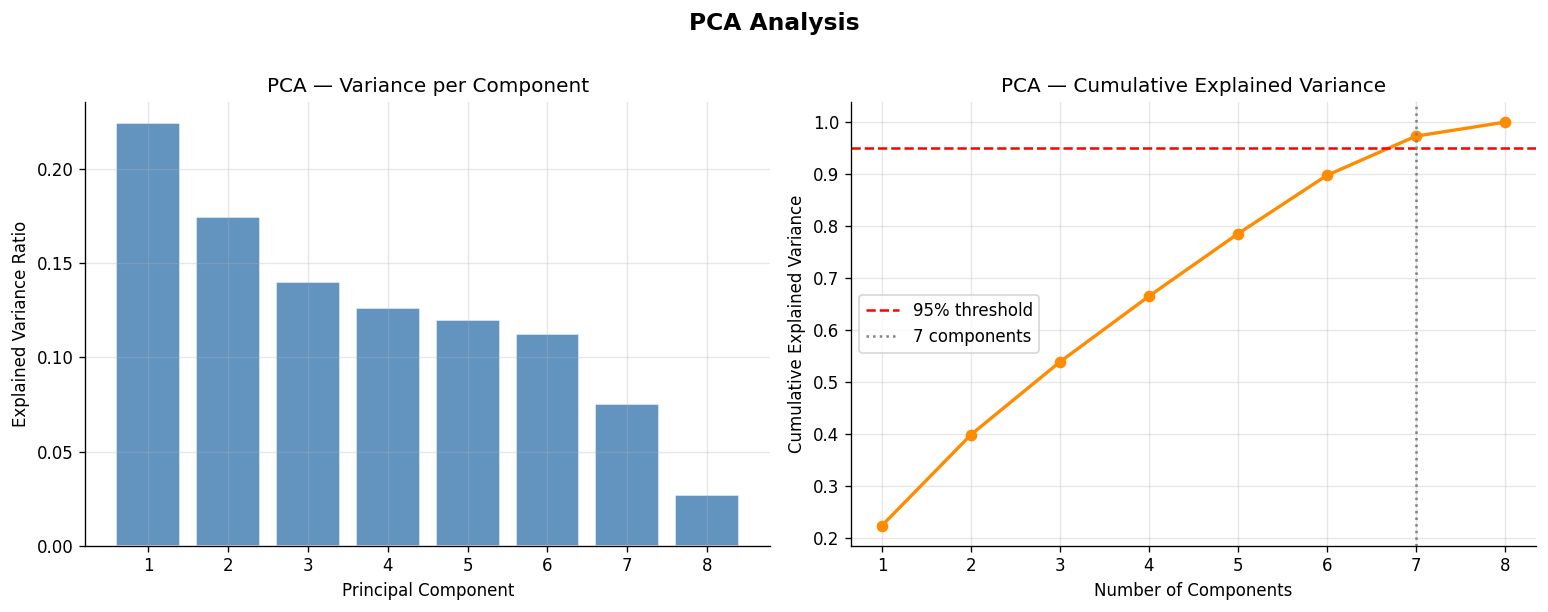

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(explained) + 1), explained, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA — Variance per Component')

axes[1].plot(range(1, len(cumulative) + 1), cumulative, 'o-', color='darkorange', lw=2)
axes[1].axhline(0.95, linestyle='--', color='red', label='95% threshold')
axes[1].axvline(n_comp_95, linestyle=':', color='gray', label=f'{n_comp_95} components')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('PCA — Cumulative Explained Variance')
axes[1].legend()

plt.suptitle('PCA Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pca_variance.png', bbox_inches='tight')
plt.show()

---
## 5. Spatial Clustering — K-Means

In [18]:
SPATIAL_FEATURES = ['Latitude', 'Longitude']
coords           = df_sample[SPATIAL_FEATURES].dropna().values
scaler_spatial   = StandardScaler()
coords_scaled    = scaler_spatial.fit_transform(coords)

In [19]:
# Elbow method — evaluate k = 2..15
inertias       = []
sil_scores_km  = []
K_RANGE        = range(2, 16)

print('Running elbow method...')
for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(coords_scaled)
    inertias.append(km.inertia_)
    sil    = silhouette_score(coords_scaled, labels, sample_size=5000, random_state=RANDOM_STATE)
    sil_scores_km.append(sil)
    print(f'  k={k:2d} | inertia={km.inertia_:>12,.0f} | silhouette={sil:.4f}')

Running elbow method...
  k= 2 | inertia=     101,223 | silhouette=0.4719
  k= 3 | inertia=      76,924 | silhouette=0.4323
  k= 4 | inertia=      55,296 | silhouette=0.4390
  k= 5 | inertia=      41,640 | silhouette=0.4131
  k= 6 | inertia=      34,662 | silhouette=0.4068
  k= 7 | inertia=      28,172 | silhouette=0.3983
  k= 8 | inertia=      23,982 | silhouette=0.3875
  k= 9 | inertia=      20,461 | silhouette=0.4012
  k=10 | inertia=      17,729 | silhouette=0.4050
  k=11 | inertia=      15,585 | silhouette=0.4149
  k=12 | inertia=      14,239 | silhouette=0.4117
  k=13 | inertia=      12,985 | silhouette=0.4109
  k=14 | inertia=      11,835 | silhouette=0.4029
  k=15 | inertia=      10,893 | silhouette=0.3978


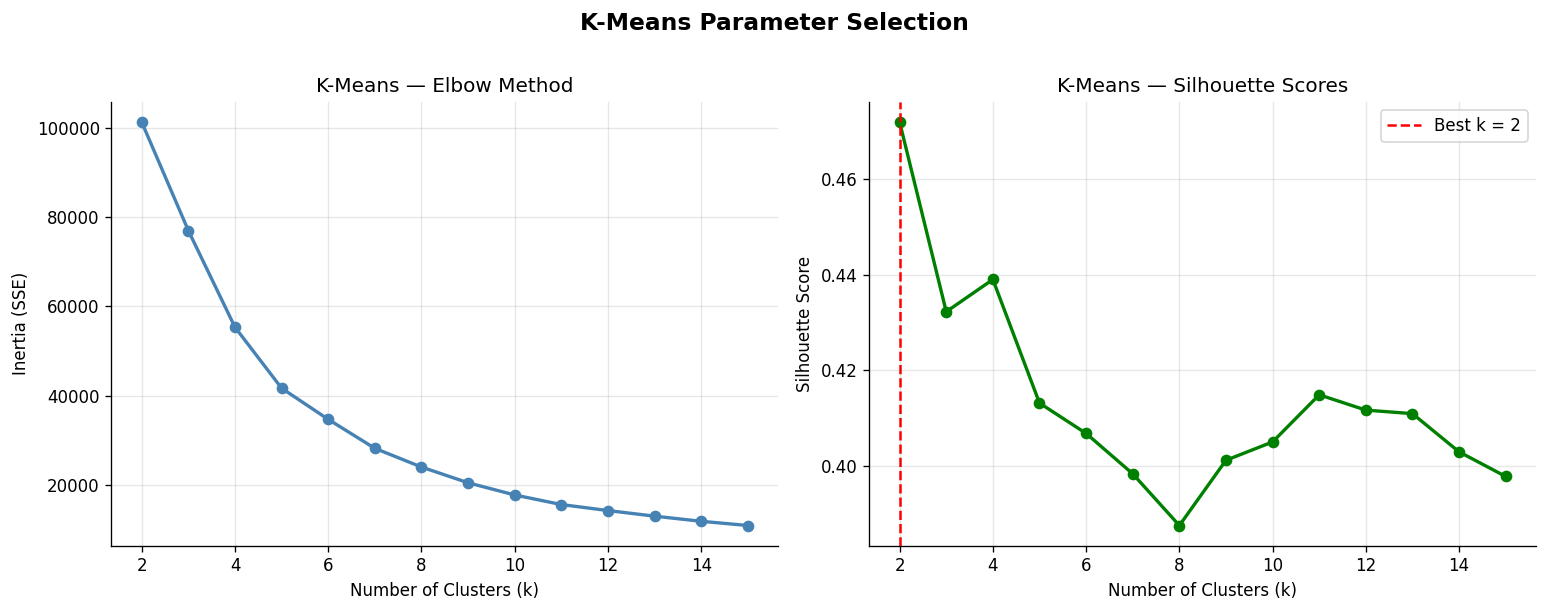

Best k (by silhouette): 2


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_RANGE, inertias, 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].set_title('K-Means — Elbow Method')

axes[1].plot(K_RANGE, sil_scores_km, 'o-', color='green', lw=2)
best_k = list(K_RANGE)[np.argmax(sil_scores_km)]
axes[1].axvline(best_k, linestyle='--', color='red', label=f'Best k = {best_k}')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('K-Means — Silhouette Scores')
axes[1].legend()

plt.suptitle('K-Means Parameter Selection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('kmeans_elbow.png', bbox_inches='tight')
plt.show()
print(f'Best k (by silhouette): {best_k}')

In [21]:
# Fit final K-Means with best k
km_final  = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
km_labels = km_final.fit_predict(coords_scaled)
df_sample = df_sample.copy()
df_sample['KMeans_Cluster'] = km_labels

# Patrol points = cluster centroids (inverse-transformed to lat/lon)
centroids_geo = scaler_spatial.inverse_transform(km_final.cluster_centers_)
centroids_df  = pd.DataFrame(centroids_geo, columns=['Latitude', 'Longitude'])
centroids_df.index.name = 'Cluster'

print(f'Recommended patrol points (k={best_k} centroids):')
centroids_df

Recommended patrol points (k=2 centroids):


,Latitude,Longitude
Cluster,,
0,41.759712,-87.628317
1,41.904674,-87.705472


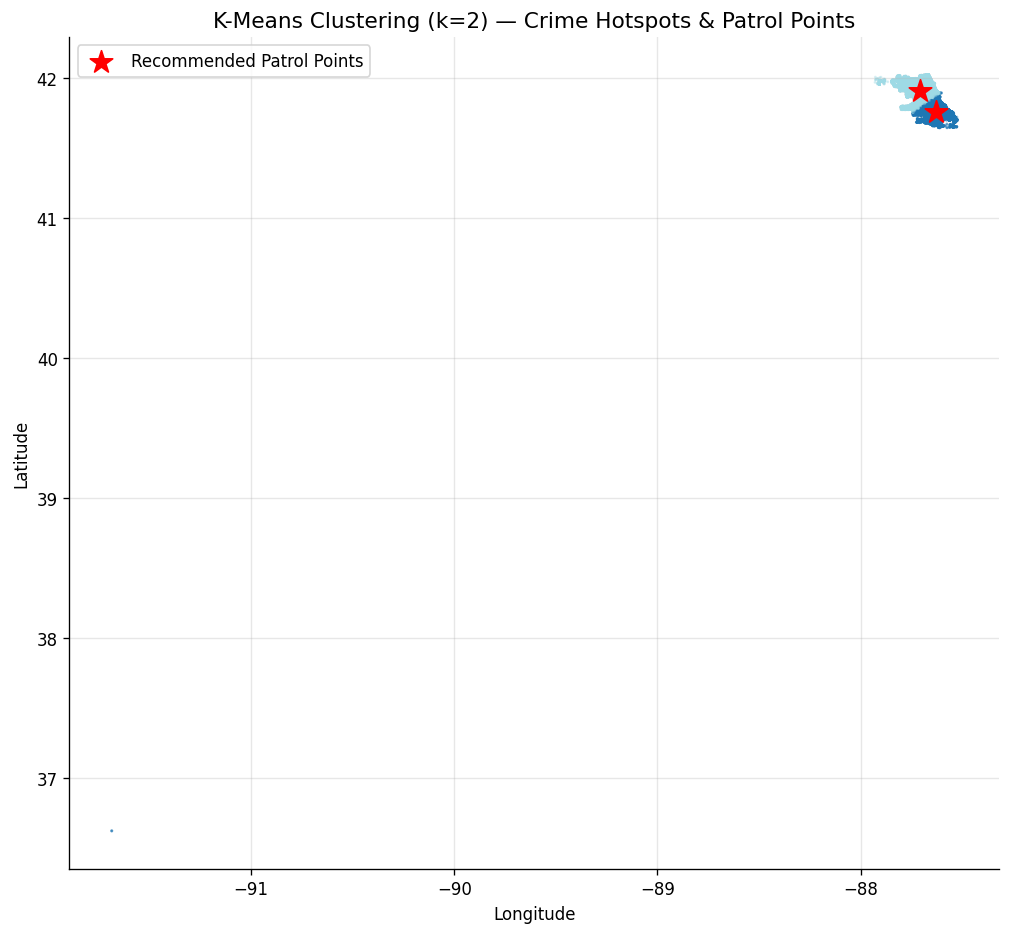

In [ ]:
plt.figure(figsize=(10, 9))
scatter = plt.scatter(
    df_sample['Longitude'], df_sample['Latitude'],
    c=km_labels, cmap='tab20', s=0.6, alpha=0.35
)
plt.scatter(
    centroids_df['Longitude'], centroids_df['Latitude'],
    c='red', s=200, marker='*', zorder=5, label='Recommended Patrol Points'
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'K-Means Clustering (k={best_k}) — Crime Hotspots & Patrol Points', fontsize=13)
plt.legend(markerscale=1, fontsize=10)
plt.show()

---
## 6. Spatial Clustering — DBSCAN

In [25]:
DBSCAN_SAMPLE  = 30_000
df_db          = df_sample.sample(n=min(DBSCAN_SAMPLE, len(df_sample)), random_state=RANDOM_STATE)
coords_db_raw  = df_db[SPATIAL_FEATURES].dropna().values
coords_db_sc   = scaler_spatial.transform(coords_db_raw)

# Grid search
eps_values         = [0.05, 0.10, 0.15, 0.20]
min_samples_values = [10, 20, 30]

best_sil_db    = -1
best_eps       = None
best_min_s     = None
best_db_labels = None

print('DBSCAN parameter grid search:')
for eps in eps_values:
    for ms in min_samples_values:
        db  = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
        lbl = db.fit_predict(coords_db_sc)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise_pct  = (lbl == -1).sum() / len(lbl) * 100
        if n_clusters < 2:
            print(f'  eps={eps}, min_s={ms:2d} | clusters={n_clusters} | noise={noise_pct:.1f}% — skip')
            continue
        sil = silhouette_score(coords_db_sc, lbl, sample_size=min(5000, len(lbl)), random_state=RANDOM_STATE)
        print(f'  eps={eps}, min_s={ms:2d} | clusters={n_clusters:3d} | noise={noise_pct:.1f}% | sil={sil:.4f}')
        if sil > best_sil_db:
            best_sil_db, best_eps, best_min_s, best_db_labels = sil, eps, ms, lbl

print(f'\nBest: eps={best_eps}, min_samples={best_min_s}, silhouette={best_sil_db:.4f}')

DBSCAN parameter grid search:
  eps=0.05, min_s=10 | clusters= 35 | noise=2.2% | sil=-0.3503
  eps=0.05, min_s=20 | clusters= 37 | noise=8.2% | sil=-0.4094
  eps=0.05, min_s=30 | clusters= 50 | noise=18.7% | sil=-0.3308
  eps=0.1, min_s=10 | clusters=  6 | noise=0.2% | sil=-0.0225
  eps=0.1, min_s=20 | clusters=  5 | noise=0.6% | sil=-0.0263
  eps=0.1, min_s=30 | clusters=  7 | noise=1.6% | sil=-0.0882
  eps=0.15, min_s=10 | clusters=  2 | noise=0.1% | sil=0.5517
  eps=0.15, min_s=20 | clusters=  3 | noise=0.1% | sil=0.1059
  eps=0.15, min_s=30 | clusters=  4 | noise=0.2% | sil=0.0986
  eps=0.2, min_s=10 | clusters=  2 | noise=0.0% | sil=0.5517
  eps=0.2, min_s=20 | clusters=  2 | noise=0.0% | sil=0.5517
  eps=0.2, min_s=30 | clusters=  2 | noise=0.0% | sil=0.5517

Best: eps=0.15, min_samples=10, silhouette=0.5517


Clusters found: 2 | Noise points: 18 (0.1%)


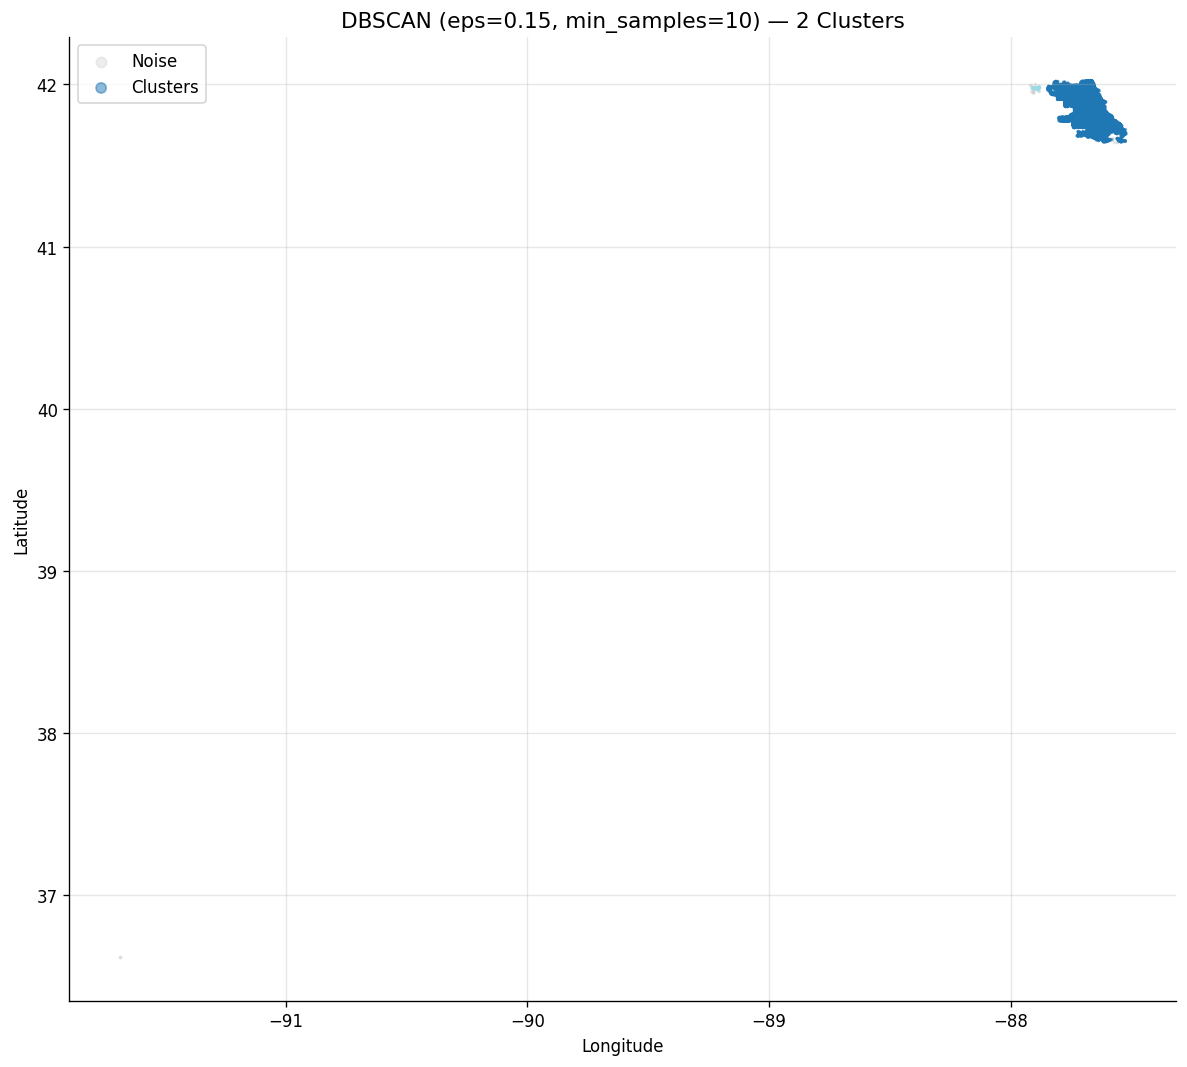

In [26]:
df_db = df_db.copy()
df_db['DBSCAN_Cluster'] = best_db_labels

n_noise      = (best_db_labels == -1).sum()
n_db_clusters = len(set(best_db_labels)) - (1 if -1 in best_db_labels else 0)
print(f'Clusters found: {n_db_clusters} | Noise points: {n_noise} ({n_noise/len(best_db_labels)*100:.1f}%)')

plt.figure(figsize=(10, 9))
mask_noise = best_db_labels == -1
plt.scatter(
    df_db.loc[mask_noise, 'Longitude'], df_db.loc[mask_noise, 'Latitude'],
    c='lightgray', s=1.5, alpha=0.4, label='Noise'
)
plt.scatter(
    df_db.loc[~mask_noise, 'Longitude'], df_db.loc[~mask_noise, 'Latitude'],
    c=best_db_labels[~mask_noise], cmap='tab20', s=1.5, alpha=0.5, label='Clusters'
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'DBSCAN (eps={best_eps}, min_samples={best_min_s}) — {n_db_clusters} Clusters', fontsize=13)
plt.legend(markerscale=5, fontsize=10)
plt.tight_layout()
plt.savefig('dbscan_clusters.png', bbox_inches='tight')
plt.show()

---
## 7. Outlier Detection — Isolation Forest

In [27]:
iso_features = ['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month']
X_iso        = df_sample[iso_features].dropna()
scaler_iso   = StandardScaler()
X_iso_scaled = scaler_iso.fit_transform(X_iso)

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.02,   # assume ~2% outliers
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_preds    = iso_forest.fit_predict(X_iso_scaled)
outlier_mask = iso_preds == -1

print(f'Outliers detected: {outlier_mask.sum():,} ({outlier_mask.mean()*100:.2f}%)')

Outliers detected: 2,000 (2.00%)


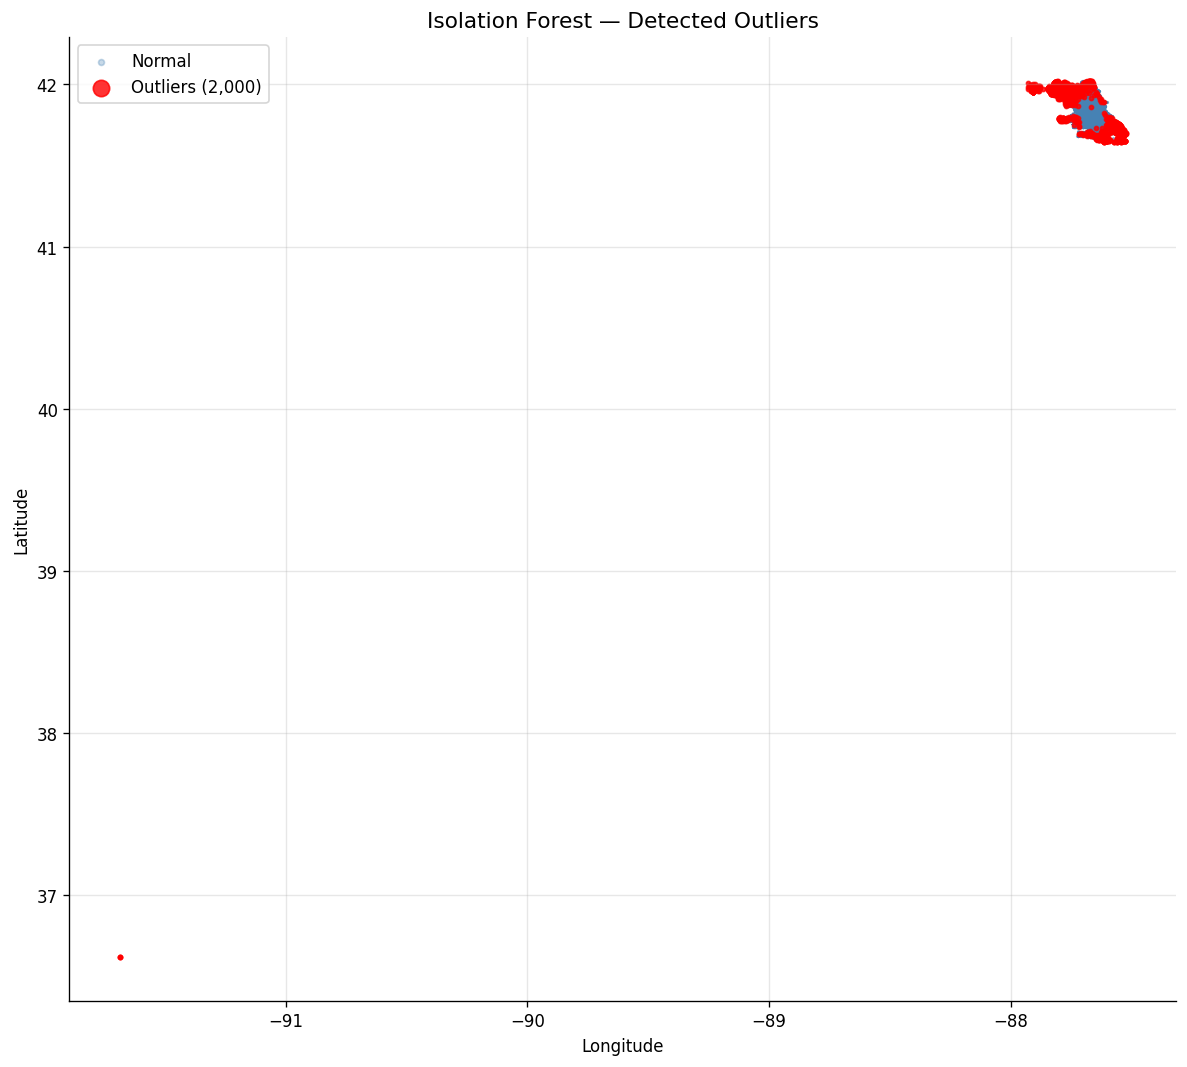

In [28]:
X_iso_df = X_iso.copy()
X_iso_df['IsOutlier'] = outlier_mask

plt.figure(figsize=(10, 9))
plt.scatter(
    X_iso_df.loc[~outlier_mask, 'Longitude'], X_iso_df.loc[~outlier_mask, 'Latitude'],
    c='steelblue', s=0.8, alpha=0.3, label='Normal'
)
plt.scatter(
    X_iso_df.loc[outlier_mask, 'Longitude'], X_iso_df.loc[outlier_mask, 'Latitude'],
    c='red', s=6, alpha=0.8, label=f'Outliers ({outlier_mask.sum():,})'
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Isolation Forest — Detected Outliers', fontsize=13)
plt.legend(markerscale=4, fontsize=10)
plt.tight_layout()
plt.savefig('outlier_detection.png', bbox_inches='tight')
plt.show()

---
## 8. Predictive Modeling — Random Forest

In [29]:
# Align outlier flags back to df_sample
df_aligned             = df_sample.copy()
df_aligned             = df_aligned.loc[X_iso.index]
df_aligned['IsOutlier'] = iso_preds
df_model               = df_aligned[df_aligned['IsOutlier'] != -1].copy()

model_cols = ['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Arrest', 'Domestic']
model_cols = [c for c in model_cols if c in df_model.columns]
X_model    = df_model[model_cols].dropna()
y_model    = df_model.loc[X_model.index, 'CrimeGroup']

print(f'Training set: {len(X_model):,} samples | {y_model.nunique()} crime groups')
print(y_model.value_counts())

Training set: 98,000 samples | 11 crime groups
CrimeGroup
THEFT                  22346
BATTERY                17757
CRIMINAL DAMAGE        10547
NARCOTICS               9065
OTHER                   7828
ASSAULT                 6192
BURGLARY                5728
OTHER OFFENSE           5707
DECEPTIVE PRACTICE      4786
MOTOR VEHICLE THEFT     4059
ROBBERY                 3985
Name: count, dtype: int64


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=RANDOM_STATE, stratify=y_model
)

scaler_model = StandardScaler()
X_train_s    = scaler_model.fit_transform(X_train)
X_test_s     = scaler_model.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
y_pred = rf.predict(X_test_s)
acc    = (y_pred == y_test).mean()

print(f'Test Accuracy: {acc:.4f}  (baseline ≈ {y_train.value_counts(normalize=True).max():.4f})')
print()
print(classification_report(y_test, y_pred, zero_division=0))

Test Accuracy: 0.3066  (baseline ≈ 0.2280)

                     precision    recall  f1-score   support

            ASSAULT       0.13      0.03      0.05      1238
            BATTERY       0.59      0.44      0.51      3552
           BURGLARY       0.15      0.38      0.22      1146
    CRIMINAL DAMAGE       0.21      0.16      0.18      2109
 DECEPTIVE PRACTICE       0.15      0.31      0.20       957
MOTOR VEHICLE THEFT       0.09      0.17      0.12       812
          NARCOTICS       0.48      0.86      0.62      1813
              OTHER       0.28      0.18      0.22      1566
      OTHER OFFENSE       0.20      0.07      0.10      1141
            ROBBERY       0.10      0.25      0.15       797
              THEFT       0.53      0.24      0.33      4469

           accuracy                           0.31     19600
          macro avg       0.26      0.28      0.24     19600
       weighted avg       0.36      0.31      0.30     19600



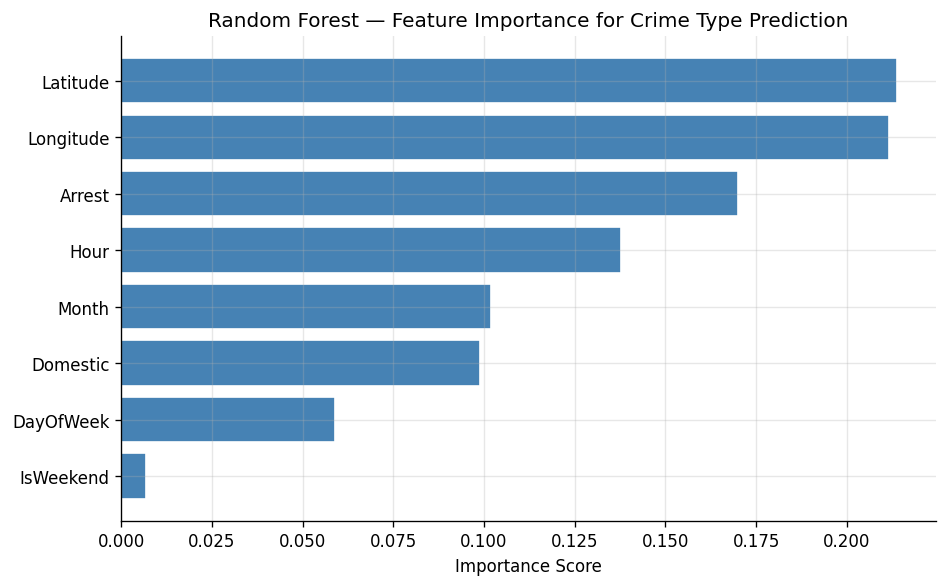

In [31]:
# Feature importance
feat_imp_df = pd.DataFrame({'Feature': model_cols, 'Importance': rf.feature_importances_})\
    .sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='steelblue', edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Random Forest — Feature Importance for Crime Type Prediction', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

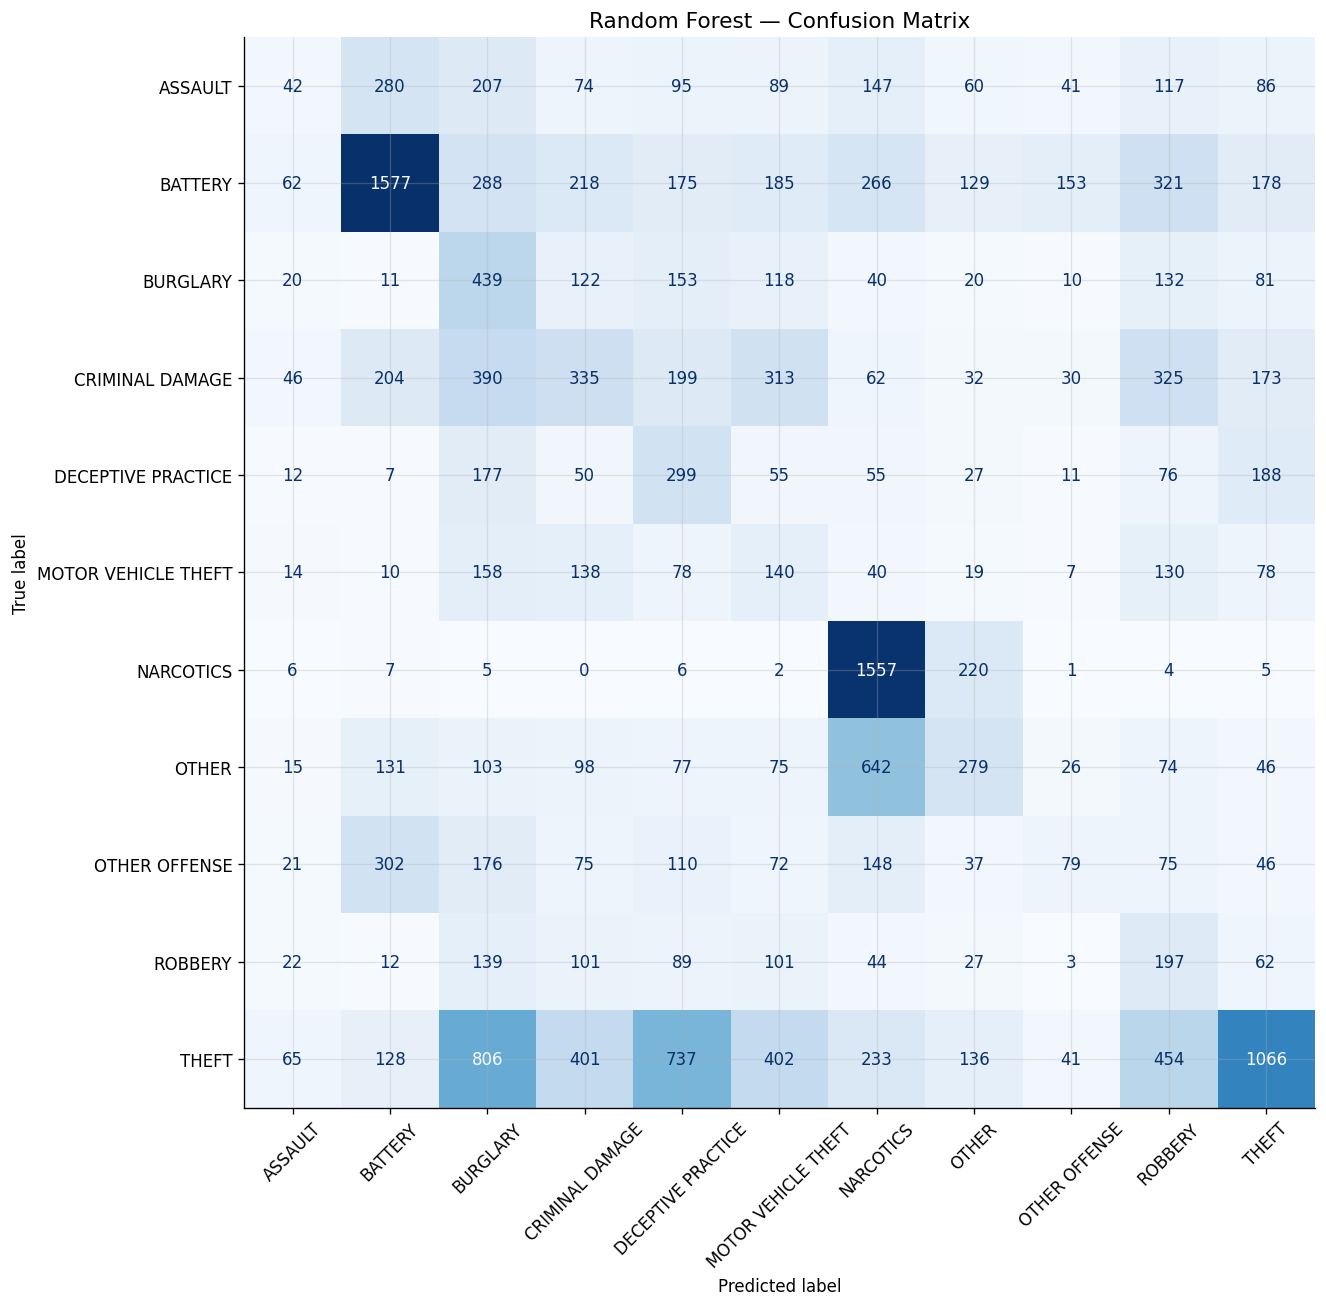

In [32]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(13, 11))
cm   = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=rf.classes_)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## 9. Patrol Distance Analysis

In [33]:
def haversine(lat1, lon1, lat2, lon2):
    """Return great-circle distance in km."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

crime_lats  = df_sample['Latitude'].values
crime_lons  = df_sample['Longitude'].values
patrol_lats = centroids_df['Latitude'].values
patrol_lons = centroids_df['Longitude'].values

# Sample 10k crimes for speed
idx = np.random.choice(len(crime_lats), size=min(10_000, len(crime_lats)), replace=False)
min_dists = [
    min(haversine(crime_lats[i], crime_lons[i], patrol_lats[j], patrol_lons[j])
        for j in range(len(patrol_lats)))
    for i in idx
]
min_dists = np.array(min_dists)

print(f'Mean distance crime → nearest patrol: {min_dists.mean():.3f} km')
print(f'Median distance:                      {np.median(min_dists):.3f} km')
print(f'90th percentile distance:             {np.percentile(min_dists, 90):.3f} km')

Mean distance crime → nearest patrol: 5.642 km
Median distance:                      5.397 km
90th percentile distance:             9.046 km


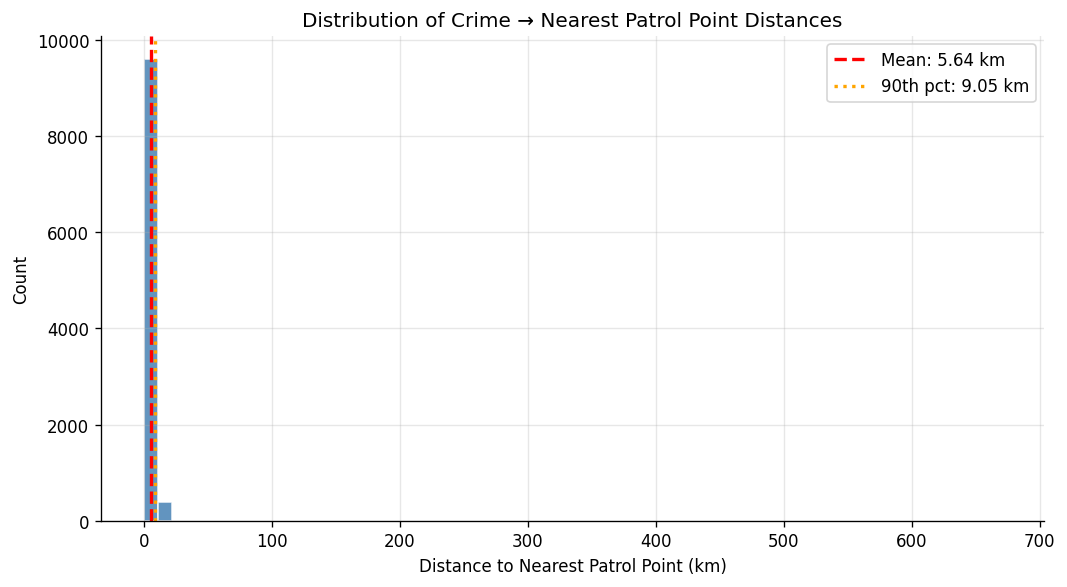

In [34]:
plt.figure(figsize=(9, 5))
plt.hist(min_dists, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(min_dists.mean(), color='red', linestyle='--', lw=2, label=f'Mean: {min_dists.mean():.2f} km')
plt.axvline(np.percentile(min_dists, 90), color='orange', linestyle=':', lw=2,
            label=f'90th pct: {np.percentile(min_dists, 90):.2f} km')
plt.xlabel('Distance to Nearest Patrol Point (km)')
plt.ylabel('Count')
plt.title('Distribution of Crime → Nearest Patrol Point Distances', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('patrol_distances.png', bbox_inches='tight')
plt.show()

---
## 10. Crime Trend Visualizations

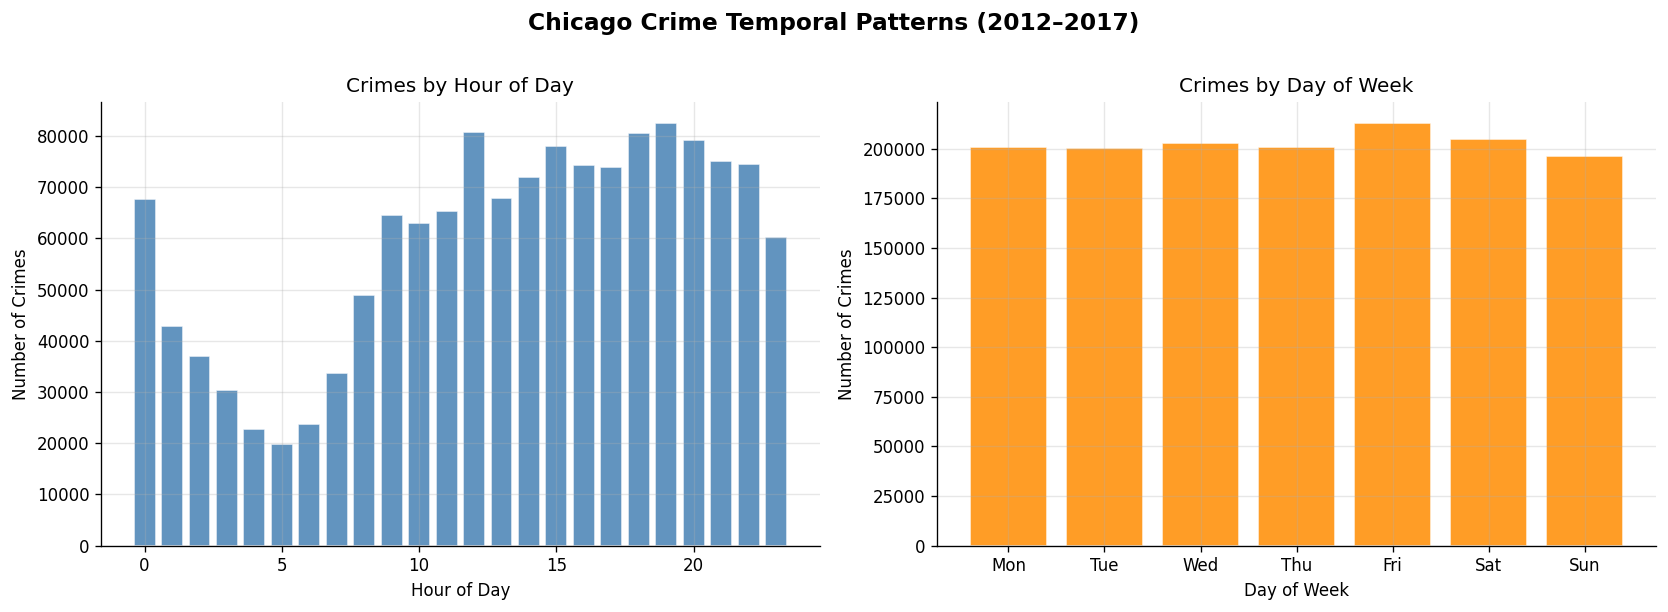

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By hour
hour_counts = df['Hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Crimes')
axes[0].set_title('Crimes by Hour of Day')

# By day of week
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts = df['DayOfWeek'].value_counts().sort_index()
axes[1].bar(dow_labels, dow_counts.values, color='darkorange', alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Crimes')
axes[1].set_title('Crimes by Day of Week')

plt.suptitle('Chicago Crime Temporal Patterns (2012–2017)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('crime_trends.png', bbox_inches='tight')
plt.show()

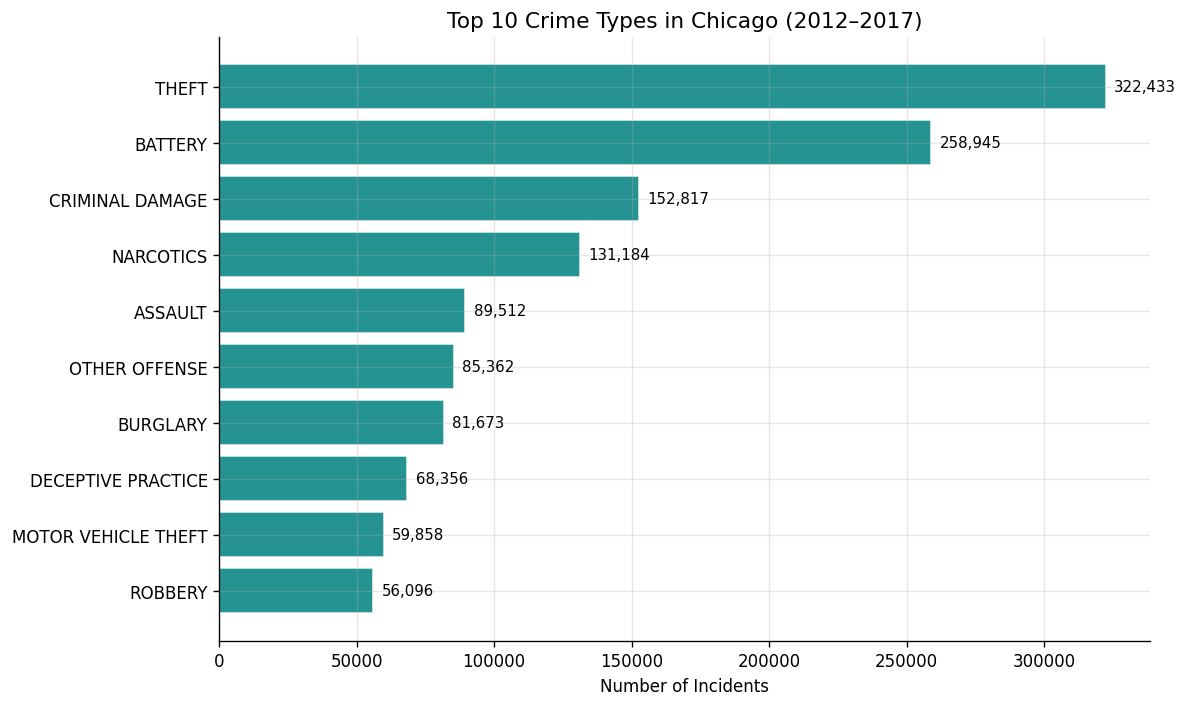

In [36]:
# Top 10 crime types
top10 = df['Primary Type'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color='teal', alpha=0.85, edgecolor='white')
ax.bar_label(bars, labels=[f'{v:,}' for v in top10.values[::-1]], padding=5, fontsize=9)
ax.set_xlabel('Number of Incidents')
ax.set_title('Top 10 Crime Types in Chicago (2012–2017)', fontsize=13)
plt.tight_layout()
plt.savefig('top_crimes.png', bbox_inches='tight')
plt.show()

---
## 11. Pipeline Summary

In [37]:
summary = {
    'Dataset Entries': f'{len(df):,}',
    'Total Attributes': df.shape[1],
    'PCA Components (95% var)': n_comp_95,
    'K-Means Best k': best_k,
    'K-Means Silhouette': f'{max(sil_scores_km):.4f}',
    'DBSCAN Best eps': best_eps,
    'DBSCAN Best min_samples': best_min_s,
    'DBSCAN Clusters Found': n_db_clusters,
    'DBSCAN Silhouette': f'{best_sil_db:.4f}',
    'Outliers Removed': f'{outlier_mask.sum():,}',
    'RF Test Accuracy': f'{acc:.4f}',
    'Mean Crime→Patrol Distance': f'{min_dists.mean():.3f} km',
    '90th Pct Distance': f'{np.percentile(min_dists, 90):.3f} km',
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
summary_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Metric,Value
Dataset Entries,"1,419,631"
Total Attributes,29
PCA Components (95% var),7
K-Means Best k,2
K-Means Silhouette,0.4719
DBSCAN Best eps,0.150000
DBSCAN Best min_samples,10
DBSCAN Clusters Found,2
DBSCAN Silhouette,0.5517
Outliers Removed,"2,000"
